In [ ]:
# Explainable Indian Legal Judgment Prediction Using InLegalBERT, TF-IDF Baselines, and SHAP-Based Interpretability on the Jud-IPL Dataset

# Partha Pratim Ray, Sikkim University, India ppray@cus.ac.in; parthapratimray1986@gmail.com

In [3]:
# Cell 1: Install required packages

!pip -q install kaggle transformers datasets evaluate accelerate shap lime optuna sentencepiece openpyxl

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 18.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 34.7 MB/s eta 0:00:00


In [4]:
#Cell 2: Import libraries

import os
import re
import json
import time
import random
import warnings
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score
)

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline

import torch
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
    set_seed
)

from datasets import Dataset
import evaluate

In [5]:
#Cell 3: Reproducibility setup

import random
import numpy as np
import torch
from transformers import set_seed

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
set_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print("CUDA available:", torch.cuda.is_available())
print("Device selected:", DEVICE)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("No GPU detected. The notebook will use CPU-safe settings.")

CUDA available: True
Device selected: cuda
GPU: Tesla T4


In [6]:
#Cell 4A: Configure Kaggle token

import os
from getpass import getpass

KAGGLE_API_TOKEN = getpass("Paste your Kaggle API token here: ")

os.makedirs("/root/.kaggle", exist_ok=True)

with open("/root/.kaggle/access_token", "w") as f:
    f.write(KAGGLE_API_TOKEN.strip())

os.chmod("/root/.kaggle/access_token", 0o600)

print("Kaggle API token configured securely.")

Paste your Kaggle API token here: ··········
Kaggle API token configured securely.


In [8]:
#Cell 4B: Test Kaggle access
!kaggle competitions list

ref                                                                              deadline             category         reward  teamCount  userHasEntered  
-------------------------------------------------------------------------------  -------------------  --------  -------------  ---------  --------------  
https://www.kaggle.com/competitions/passenger-screening-algorithm-challenge      2017-12-15 23:59:00  Featured  1,500,000 Usd        518           False  
https://www.kaggle.com/competitions/zillow-prize-1                               2018-01-10 15:59:00  Featured  1,200,000 Usd       3770           False  
https://www.kaggle.com/competitions/data-science-bowl-2017                       2017-04-12 23:59:00  Featured  1,000,000 Usd       1972           False  
https://www.kaggle.com/competitions/vesuvius-challenge-ink-detection             2023-06-14 23:59:00  Featured  1,000,000 Usd       1249           False  
https://www.kaggle.com/competitions/arc-prize-2026-arc-agi-3          

In [9]:
#Cell 5: Download Jud-IPL dataset

!mkdir -p /content/judipl

!kaggle datasets download \
-d bhavyabj/jud-ipl-indian-legal-judgement-prediction-dataset \
-p /content/judipl \
--unzip

Dataset URL: https://www.kaggle.com/datasets/bhavyabj/jud-ipl-indian-legal-judgement-prediction-dataset
License(s): CC0-1.0
100% 240M/240M [00:15<00:00, 16.5MB/s]



In [10]:
#Cell 6: Locate dataset file

import os

for root, dirs, files in os.walk("/content/judipl"):
    for file in files:
        print(os.path.join(root, file))

/content/judipl/case_files_total.csv


In [11]:
#Cell 7: Load dataset

DATA_PATH = "/content/judipl/case_files_total.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (53446, 10)


,Unnamed: 0,name,case_category,case_type,case_info,judgement,tokens,sentences,label,proof_sentence
0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,74634371.txt,civil,writ petition,reportable in the supreme court of india civil...,thus spake benjamin franklin in his letter of ...,9974.0,254.0,Accepted,"34. we are, therefore, of the view that this a..."
2,2,746230.txt,civil,writ petition,case number appeal civil 588 of 1972 petitio...,difficult to share the view taken by the high...,1411.0,56.0,Accepted,"6. accordingly, we allow the appeal with costs."
3,3,746330.txt,civil,writ petition,petitioner western india plywood limited vs. r...,j u d g m e n t the following judgement of the...,2616.0,85.0,Accepted,for the aforesaid reasons this appeal is allowed.
4,4,746327.txt,civil,writ petition,"petitioner asstt.\ncustodian, e.p. ors.\nvs. r...",custodian first stated that the property was n...,2763.0,95.0,Accepted,appeal allowed.


In [12]:
#Cell 8: Basic dataset audit
audit_table = pd.DataFrame({
    "Column": df.columns,
    "Non_Null_Count": df.notnull().sum().values,
    "Null_Count": df.isnull().sum().values,
    "Null_Percentage": (df.isnull().mean().values * 100).round(2),
    "Unique_Values": df.nunique(dropna=True).values,
    "Data_Type": df.dtypes.astype(str).values
})

audit_table

,Column,Non_Null_Count,Null_Count,Null_Percentage,Unique_Values,Data_Type
0,Unnamed: 0,53446,0,0.00,43785,int64
1,name,53445,1,0.00,44677,object
2,case_category,43612,9834,18.40,2,object
3,case_type,52710,736,1.38,12,object
4,case_info,53421,25,0.05,39772,object
5,judgement,50144,3302,6.18,41007,object
6,tokens,53444,2,0.00,10808,float64
7,sentences,53444,2,0.00,1080,float64
8,label,53444,2,0.00,3,object
9,proof_sentence,53444,2,0.00,28740,object


In [13]:
# Cell 9: Clean labels and remove unusable rows

#For judgment prediction, keep only Accepted and Rejected labels. Remove Other and missing labels.

df_clean = df.copy()

df_clean["label"] = df_clean["label"].astype(str).str.strip()
df_clean["case_category"] = df_clean["case_category"].astype(str).str.strip().str.lower()

df_binary = df_clean[df_clean["label"].isin(["Accepted", "Rejected"])].copy()

df_binary["target"] = df_binary["label"].map({
    "Rejected": 0,
    "Accepted": 1
})

df_binary = df_binary.dropna(subset=["judgement", "target"])

df_binary["judgement"] = df_binary["judgement"].astype(str)
df_binary["case_info"] = df_binary["case_info"].fillna("").astype(str)
df_binary["proof_sentence"] = df_binary["proof_sentence"].fillna("").astype(str)

print("Original shape:", df.shape)
print("Binary cleaned shape:", df_binary.shape)
print(df_binary["label"].value_counts())

Original shape: (53446, 10)
Binary cleaned shape: (42342, 11)
label
Rejected    22510
Accepted    19832
Name: count, dtype: int64


In [14]:
# Cell 10: Create final text field

#A wise approach is to combine case_info, judgement, and optionally proof_sentence.


def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"\s+", " ", text)
    text = re.sub(r"[^a-z0-9.,;:()/%\- ]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df_binary["text"] = (
    df_binary["case_info"].fillna("") + " " +
    df_binary["judgement"].fillna("")
)

df_binary["text"] = df_binary["text"].apply(clean_text)

df_binary["text_length_words"] = df_binary["text"].apply(lambda x: len(x.split()))

df_binary[["name", "case_category", "case_type", "label", "target", "text_length_words"]].head()

,name,case_category,case_type,label,target,text_length_words
1,74634371.txt,civil,writ petition,Accepted,1,5807
2,746230.txt,civil,writ petition,Accepted,1,1411
3,746330.txt,civil,writ petition,Accepted,1,2580
4,746327.txt,civil,writ petition,Accepted,1,2706
5,746119.txt,criminal,special leave petition,Rejected,0,2388


In [15]:
# Cell 11: Descriptive statistics

desc_table = df_binary[["tokens", "sentences", "text_length_words"]].describe().T.round(2)
desc_table

,count,mean,std,min,25%,50%,75%,max
tokens,42342.0,3798.39,6294.04,0.0,1272.0,2603.0,4579.0,416861.0
sentences,42342.0,116.61,182.25,0.0,42.0,81.0,140.0,11015.0
text_length_words,42342.0,2933.51,1825.11,155.0,1392.0,2603.0,4420.0,7038.0


In [16]:
#Cell 12: Publication-grade plotting style

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 9,
    "figure.figsize": (7, 5),
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False
})

FIG_DIR = "/content/figures"
TAB_DIR = "/content/tables"

os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(TAB_DIR, exist_ok=True)

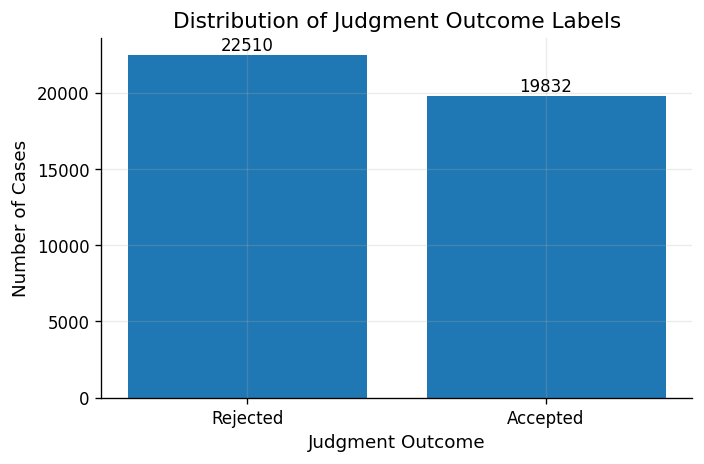

,Label,Count,Percentage
0,Rejected,22510,53.16
1,Accepted,19832,46.84


In [17]:
#Cell 13: Label distribution plot

label_counts = df_binary["label"].value_counts().reset_index()
label_counts.columns = ["Label", "Count"]
label_counts["Percentage"] = (label_counts["Count"] / label_counts["Count"].sum() * 100).round(2)

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(label_counts["Label"], label_counts["Count"])

for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{int(height)}",
        ha="center",
        va="bottom",
        fontsize=10
    )

ax.set_title("Distribution of Judgment Outcome Labels")
ax.set_xlabel("Judgment Outcome")
ax.set_ylabel("Number of Cases")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/label_distribution.png", bbox_inches="tight")
plt.show()

label_counts

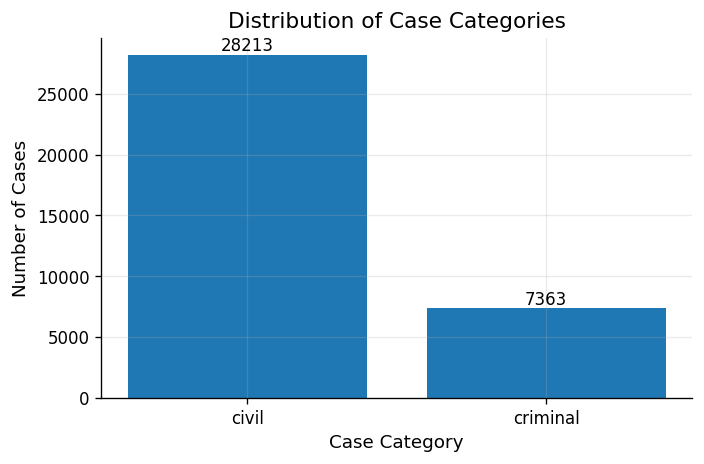

,Case_Category,Count,Percentage
0,civil,28213,79.3
1,criminal,7363,20.7


In [18]:
#Cell 14: Case category distribution

category_counts = (
    df_binary["case_category"]
    .replace("nan", np.nan)
    .dropna()
    .value_counts()
    .reset_index()
)

category_counts.columns = ["Case_Category", "Count"]
category_counts["Percentage"] = (category_counts["Count"] / category_counts["Count"].sum() * 100).round(2)

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(category_counts["Case_Category"], category_counts["Count"])

for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{int(height)}",
        ha="center",
        va="bottom",
        fontsize=10
    )

ax.set_title("Distribution of Case Categories")
ax.set_xlabel("Case Category")
ax.set_ylabel("Number of Cases")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/case_category_distribution.png", bbox_inches="tight")
plt.show()

category_counts

In [21]:
#Cell 15: Outcome by case category

cat_label_table = pd.crosstab(
    df_binary["case_category"],
    df_binary["label"],
    margins=True
)

cat_label_percent = pd.crosstab(
    df_binary["case_category"],
    df_binary["label"],
    normalize="index"
).round(3) * 100

cat_label_table




label,Accepted,Rejected,All
case_category,,,
civil,13361,14852,28213
criminal,3411,3952,7363
nan,3060,3706,6766
All,19832,22510,42342


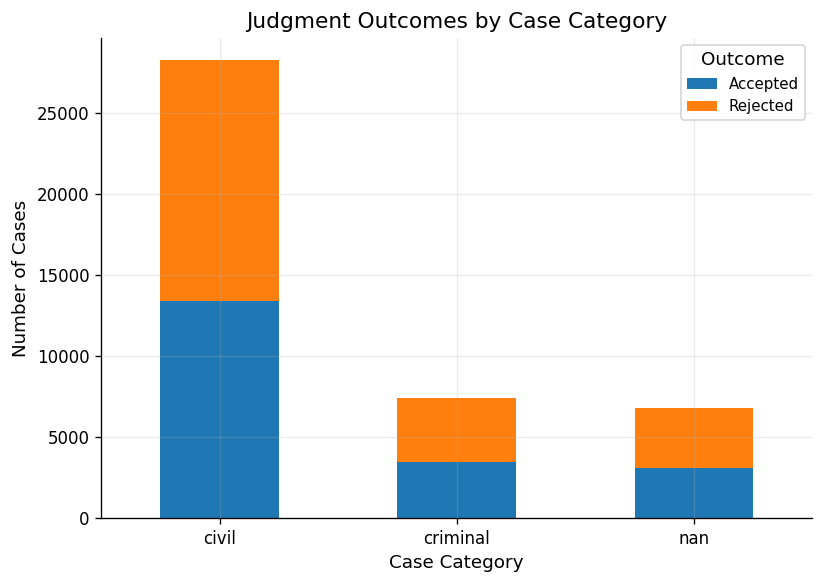

Count table
| case_category   |   Accepted |   Rejected |   All |
|:----------------|-----------:|-----------:|------:|
| civil           |      13361 |      14852 | 28213 |
| criminal        |       3411 |       3952 |  7363 |
| nan             |       3060 |       3706 |  6766 |
| All             |      19832 |      22510 | 42342 |

Percentage table
| case_category   |   Accepted |   Rejected |
|:----------------|-----------:|-----------:|
| civil           |       47.4 |       52.6 |
| criminal        |       46.3 |       53.7 |
| nan             |       45.2 |       54.8 |


In [25]:
plot_data = pd.crosstab(df_binary["case_category"], df_binary["label"])

ax = plot_data.plot(kind="bar", stacked=True, figsize=(7, 5))

ax.set_title("Judgment Outcomes by Case Category")
ax.set_xlabel("Case Category")
ax.set_ylabel("Number of Cases")
ax.legend(title="Outcome")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/outcome_by_case_category.png", bbox_inches="tight")
plt.show()


print("Count table")
print(cat_label_table.to_markdown())

print("\nPercentage table")
print(cat_label_percent.to_markdown())





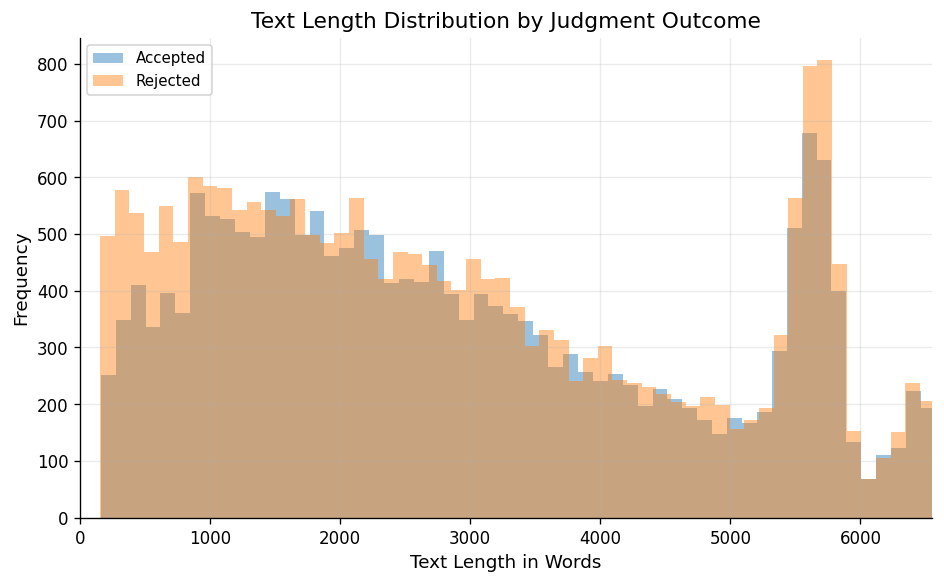

In [26]:
#Cell 16: Text length distribution by outcome

fig, ax = plt.subplots(figsize=(8, 5))

for label in df_binary["label"].unique():
    subset = df_binary[df_binary["label"] == label]["text_length_words"]
    ax.hist(
        subset,
        bins=60,
        alpha=0.45,
        label=label
    )

ax.set_title("Text Length Distribution by Judgment Outcome")
ax.set_xlabel("Text Length in Words")
ax.set_ylabel("Frequency")
ax.set_xlim(0, df_binary["text_length_words"].quantile(0.99))
ax.legend()
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/text_length_distribution.png", bbox_inches="tight")
plt.show()

In [27]:
# Cell 17: Train-test split using original no-shuffle logic

#The dataset description states an 80:20 split without shuffling. We can follow that design.

df_binary = df_binary.reset_index(drop=True)

split_idx = int(len(df_binary) * 0.80)

train_df = df_binary.iloc[:split_idx].copy()
test_df = df_binary.iloc[split_idx:].copy()

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

print("Train label distribution")
print(train_df["label"].value_counts())

print("\nTest label distribution")
print(test_df["label"].value_counts())

Train shape: (33873, 13)
Test shape: (8469, 13)
Train label distribution
label
Rejected    17946
Accepted    15927
Name: count, dtype: int64

Test label distribution
label
Rejected    4564
Accepted    3905
Name: count, dtype: int64


In [28]:
# Cell 18: Also create civil and criminal subsets

civil_df = df_binary[df_binary["case_category"] == "civil"].reset_index(drop=True)
criminal_df = df_binary[df_binary["case_category"] == "criminal"].reset_index(drop=True)

print("Civil cases:", civil_df.shape)
print(civil_df["label"].value_counts())

print("\nCriminal cases:", criminal_df.shape)
print(criminal_df["label"].value_counts())

Civil cases: (28213, 13)
label
Rejected    14852
Accepted    13361
Name: count, dtype: int64

Criminal cases: (7363, 13)
label
Rejected    3952
Accepted    3411
Name: count, dtype: int64


In [29]:
# Cell 19: Utility function for model evaluation

def evaluate_predictions(y_true, y_pred, y_prob=None, model_name="Model", subset_name="Overall"):
    acc = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )

    weighted_precision, weighted_recall, weighted_f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    result = {
        "Model": model_name,
        "Subset": subset_name,
        "Accuracy": round(acc, 4),
        "Macro_Precision": round(precision, 4),
        "Macro_Recall": round(recall, 4),
        "Macro_F1": round(f1, 4),
        "Weighted_Precision": round(weighted_precision, 4),
        "Weighted_Recall": round(weighted_recall, 4),
        "Weighted_F1": round(weighted_f1, 4)
    }

    if y_prob is not None:
        try:
            result["ROC_AUC"] = round(roc_auc_score(y_true, y_prob), 4)
            result["Average_Precision"] = round(average_precision_score(y_true, y_prob), 4)
        except Exception:
            result["ROC_AUC"] = np.nan
            result["Average_Precision"] = np.nan

    return result

In [30]:
#Cell 20: Classical ML baselines

#Use truncated text for classical models to reduce memory.

X_train = train_df["text"].values
y_train = train_df["target"].values

X_test = test_df["text"].values
y_test = test_df["target"].values

baseline_models = {
    "TFIDF_LogisticRegression": Pipeline([
        ("tfidf", TfidfVectorizer(max_features=50000, ngram_range=(1, 2), min_df=3)),
        ("clf", LogisticRegression(max_iter=2000, class_weight="balanced", n_jobs=-1))
    ]),
    "TFIDF_LinearSVC": Pipeline([
        ("tfidf", TfidfVectorizer(max_features=50000, ngram_range=(1, 2), min_df=3)),
        ("clf", LinearSVC(class_weight="balanced"))
    ]),
    "TFIDF_MultinomialNB": Pipeline([
        ("tfidf", TfidfVectorizer(max_features=50000, ngram_range=(1, 2), min_df=3)),
        ("clf", MultinomialNB())
    ])
}

baseline_results = []
baseline_predictions = {}

for model_name, model in baseline_models.items():
    print(f"\nTraining {model_name}...")
    start = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start

    y_pred = model.predict(X_test)

    if hasattr(model.named_steps["clf"], "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
    elif hasattr(model.named_steps["clf"], "decision_function"):
        scores = model.decision_function(X_test)
        y_prob = (scores - scores.min()) / (scores.max() - scores.min() + 1e-9)
    else:
        y_prob = None

    result = evaluate_predictions(
        y_true=y_test,
        y_pred=y_pred,
        y_prob=y_prob,
        model_name=model_name,
        subset_name="Overall"
    )
    result["Training_Time_Sec"] = round(train_time, 2)
    baseline_results.append(result)
    baseline_predictions[model_name] = {
        "y_pred": y_pred,
        "y_prob": y_prob
    }

baseline_results_df = pd.DataFrame(baseline_results)
baseline_results_df


Training TFIDF_LogisticRegression...

Training TFIDF_LinearSVC...

Training TFIDF_MultinomialNB...


,Model,Subset,Accuracy,Macro_Precision,Macro_Recall,Macro_F1,Weighted_Precision,Weighted_Recall,Weighted_F1,ROC_AUC,Average_Precision,Training_Time_Sec
0,TFIDF_LogisticRegression,Overall,0.8185,0.8173,0.8181,0.8176,0.8189,0.8185,0.8186,0.8967,0.8721,211.89
1,TFIDF_LinearSVC,Overall,0.9149,0.9140,0.9150,0.9144,0.9151,0.9149,0.9149,0.9710,0.9643,318.88
2,TFIDF_MultinomialNB,Overall,0.6627,0.6631,0.6539,0.6534,0.6629,0.6627,0.6578,0.7188,0.6781,267.77


In [32]:
# Cell 20A: Classical ML baselines

print(baseline_results_df.to_markdown(index=False))
baseline_results_df.to_csv(f"{TAB_DIR}/baseline_results.csv", index=False)

| Model                    | Subset   |   Accuracy |   Macro_Precision |   Macro_Recall |   Macro_F1 |   Weighted_Precision |   Weighted_Recall |   Weighted_F1 |   ROC_AUC |   Average_Precision |   Training_Time_Sec |
|:-------------------------|:---------|-----------:|------------------:|---------------:|-----------:|---------------------:|------------------:|--------------:|----------:|--------------------:|--------------------:|
| TFIDF_LogisticRegression | Overall  |     0.8185 |            0.8173 |         0.8181 |     0.8176 |               0.8189 |            0.8185 |        0.8186 |    0.8967 |              0.8721 |              211.89 |
| TFIDF_LinearSVC          | Overall  |     0.9149 |            0.914  |         0.915  |     0.9144 |               0.9151 |            0.9149 |        0.9149 |    0.971  |              0.9643 |              318.88 |
| TFIDF_MultinomialNB      | Overall  |     0.6627 |            0.6631 |         0.6539 |     0.6534 |               0.6629 |   

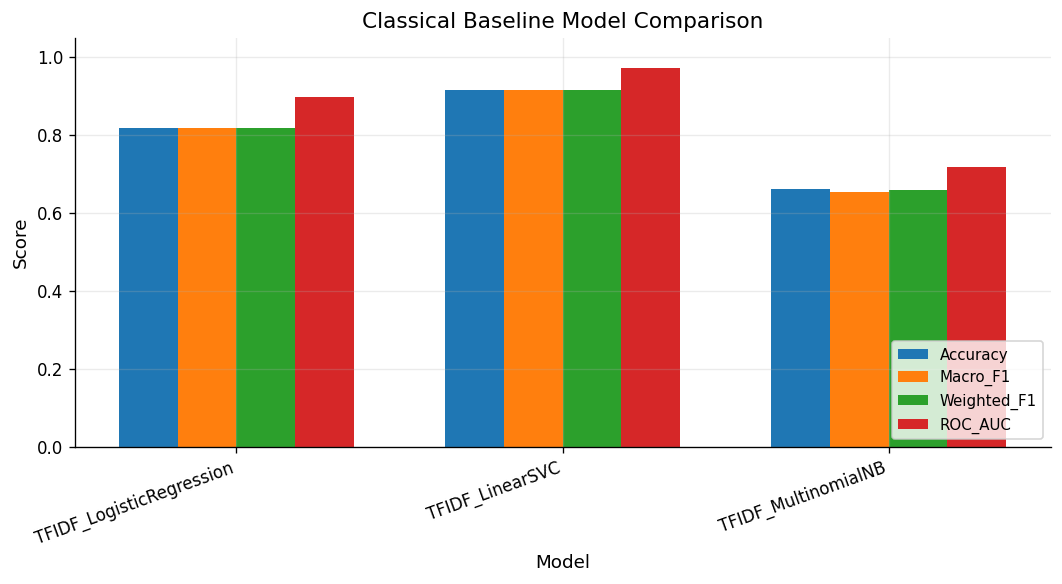

In [33]:
# Cell 21: Baseline comparison plot

metric_order = ["Accuracy", "Macro_F1", "Weighted_F1", "ROC_AUC"]
plot_df = baseline_results_df.melt(
    id_vars=["Model"],
    value_vars=[m for m in metric_order if m in baseline_results_df.columns],
    var_name="Metric",
    value_name="Score"
)

fig, ax = plt.subplots(figsize=(9, 5))

models = plot_df["Model"].unique()
metrics = plot_df["Metric"].unique()

x = np.arange(len(models))
width = 0.18

for i, metric in enumerate(metrics):
    scores = plot_df[plot_df["Metric"] == metric]["Score"].values
    ax.bar(x + i*width, scores, width, label=metric)

ax.set_title("Classical Baseline Model Comparison")
ax.set_xlabel("Model")
ax.set_ylabel("Score")
ax.set_xticks(x + width * (len(metrics)-1)/2)
ax.set_xticklabels(models, rotation=20, ha="right")
ax.set_ylim(0, 1.05)
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/baseline_model_comparison.png", bbox_inches="tight")
plt.show()

In [35]:
# Cell 22: Confusion matrix function

def plot_confusion_matrix(y_true, y_pred, title, filename):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(5, 4))
    im = ax.imshow(cm)

    ax.set_title(title)
    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("True Label")
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(["Rejected", "Accepted"])
    ax.set_yticklabels(["Rejected", "Accepted"])

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, cm[i, j], ha="center", va="center")

    plt.tight_layout()
    plt.savefig(f"{FIG_DIR}/{filename}", bbox_inches="tight")
    plt.show()

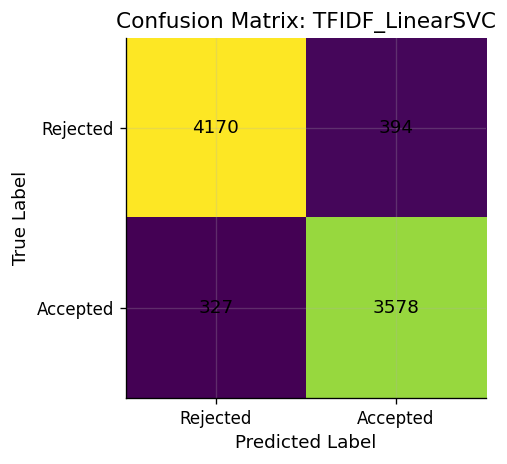

Best baseline: TFIDF_LinearSVC
              precision    recall  f1-score   support

    Rejected       0.93      0.91      0.92      4564
    Accepted       0.90      0.92      0.91      3905

    accuracy                           0.91      8469
   macro avg       0.91      0.91      0.91      8469
weighted avg       0.92      0.91      0.91      8469



In [36]:
# Cell 22A: Plot best classical model

best_baseline_name = baseline_results_df.sort_values("Macro_F1", ascending=False).iloc[0]["Model"]
best_baseline_pred = baseline_predictions[best_baseline_name]["y_pred"]

plot_confusion_matrix(
    y_test,
    best_baseline_pred,
    f"Confusion Matrix: {best_baseline_name}",
    "best_baseline_confusion_matrix.png"
)

print("Best baseline:", best_baseline_name)
print(classification_report(y_test, best_baseline_pred, target_names=["Rejected", "Accepted"]))

In [38]:
# Cell 23: Prepare smaller Transformer experiment
# CPU/GPU-safe stratified sampling for Transformer experiment

from sklearn.model_selection import train_test_split

# If no GPU, keep Transformer experiment small
if torch.cuda.is_available():
    MAX_TRAIN_SAMPLES = 6000
    MAX_TEST_SAMPLES = 2000
    BATCH_SIZE = 8
    EPOCHS = 2
    MAX_LENGTH = 512
else:
    MAX_TRAIN_SAMPLES = 800
    MAX_TEST_SAMPLES = 300
    BATCH_SIZE = 4
    EPOCHS = 1
    MAX_LENGTH = 256

# Stratified sample from train_df
if len(train_df) > MAX_TRAIN_SAMPLES:
    train_small, _ = train_test_split(
        train_df,
        train_size=MAX_TRAIN_SAMPLES,
        random_state=SEED,
        stratify=train_df["target"]
    )
else:
    train_small = train_df.copy()

# Stratified sample from test_df
if len(test_df) > MAX_TEST_SAMPLES:
    test_small, _ = train_test_split(
        test_df,
        train_size=MAX_TEST_SAMPLES,
        random_state=SEED,
        stratify=test_df["target"]
    )
else:
    test_small = test_df.copy()

train_small = train_small.reset_index(drop=True)
test_small = test_small.reset_index(drop=True)

print("CUDA available:", torch.cuda.is_available())
print("Train sample shape:", train_small.shape)
print("Test sample shape:", test_small.shape)
print("Batch size:", BATCH_SIZE)
print("Epochs:", EPOCHS)
print("Max token length:", MAX_LENGTH)

print("\nTrain label distribution:")
print(train_small["label"].value_counts())

print("\nTest label distribution:")
print(test_small["label"].value_counts())

CUDA available: True
Train sample shape: (6000, 13)
Test sample shape: (2000, 13)
Batch size: 8
Epochs: 2
Max token length: 512

Train label distribution:
label
Rejected    3179
Accepted    2821
Name: count, dtype: int64

Test label distribution:
label
Rejected    1078
Accepted     922
Name: count, dtype: int64


In [39]:
#Cell 24: Select Hugging Face model

#Recommended first model:

MODEL_NAME = "law-ai/InLegalBERT"
MAX_LENGTH = 512

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

config.json:   0%|          | 0.00/671 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/516 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

In [ ]:
# 24A: Alternative models to try later:

candidate_models = [
    "law-ai/InLegalBERT",
    "nlpaueb/legal-bert-base-uncased",
    "distilbert-base-uncased",
    "bert-base-uncased"
]

candidate_models

In [40]:
# Cell 25: Convert pandas data to Hugging Face Dataset

hf_train = Dataset.from_pandas(train_small[["text", "target"]].rename(columns={"target": "label"}))
hf_test = Dataset.from_pandas(test_small[["text", "target"]].rename(columns={"target": "label"}))

def tokenize_batch(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=MAX_LENGTH
    )

hf_train_tok = hf_train.map(tokenize_batch, batched=True)
hf_test_tok = hf_test.map(tokenize_batch, batched=True)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

Map:   0%|          | 0/6000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [41]:
# Cell 26: Define Transformer model

id2label = {
    0: "Rejected",
    1: "Accepted"
}

label2id = {
    "Rejected": 0,
    "Accepted": 1
}

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
    id2label=id2label,
    label2id=label2id
)

pytorch_model.bin:   0%|          | 0.00/534M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: law-ai/InLegalBERT
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect id

In [42]:
# Cell 27: Define metrics for Trainer

accuracy_metric = evaluate.load("accuracy")
f1_metric = evaluate.load("f1")
precision_metric = evaluate.load("precision")
recall_metric = evaluate.load("recall")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)

    return {
        "accuracy": accuracy_metric.compute(predictions=preds, references=labels)["accuracy"],
        "macro_f1": f1_metric.compute(predictions=preds, references=labels, average="macro")["f1"],
        "weighted_f1": f1_metric.compute(predictions=preds, references=labels, average="weighted")["f1"],
        "macro_precision": precision_metric.compute(predictions=preds, references=labels, average="macro", zero_division=0)["precision"],
        "macro_recall": recall_metric.compute(predictions=preds, references=labels, average="macro", zero_division=0)["recall"]
    }

In [43]:
# Cell 28: Training arguments

training_args = TrainingArguments(
    output_dir="/content/inlegalbert_judipl",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=2,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="steps",
    logging_steps=100,
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,
    report_to="none",
    seed=SEED
)

# If your Transformers version gives an error for eval_strategy, replace it with:
# evaluation_strategy="epoch"

In [45]:
# Cell 29: Train InLegalBERT
# Corrected Trainer initialization for newer Transformers versions

from transformers import Trainer
import time

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=hf_train_tok,
    eval_dataset=hf_test_tok,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    processing_class=tokenizer
)

start = time.time()
trainer.train()
transformer_train_time = time.time() - start

print("Transformer training time in seconds:", round(transformer_train_time, 2))

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1,Macro Precision,Macro Recall
1,0.702500,0.682988,0.550500,0.434764,0.454714,0.557731,0.518359
2,0.650350,0.666599,0.597000,0.593560,0.596477,0.593921,0.593434


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

Transformer training time in seconds: 1580.05


In [46]:
# Cell 30: Evaluate InLegalBERT

pred_output = trainer.predict(hf_test_tok)

logits = pred_output.predictions
y_true_transformer = pred_output.label_ids
y_pred_transformer = np.argmax(logits, axis=1)

probs = torch.softmax(torch.tensor(logits), dim=1).numpy()
y_prob_transformer = probs[:, 1]

transformer_result = evaluate_predictions(
    y_true=y_true_transformer,
    y_pred=y_pred_transformer,
    y_prob=y_prob_transformer,
    model_name="FineTuned_InLegalBERT",
    subset_name="Sampled_Test_Set"
)

transformer_result["Training_Time_Sec"] = round(transformer_train_time, 2)

transformer_results_df = pd.DataFrame([transformer_result])
transformer_results_df

,Model,Subset,Accuracy,Macro_Precision,Macro_Recall,Macro_F1,Weighted_Precision,Weighted_Recall,Weighted_F1,ROC_AUC,Average_Precision,Training_Time_Sec
0,FineTuned_InLegalBERT,Sampled_Test_Set,0.597,0.5939,0.5934,0.5936,0.5962,0.597,0.5965,0.6237,0.5717,1580.05


In [47]:
# Cell: 30A

print(transformer_results_df.to_markdown(index=False))
transformer_results_df.to_csv(f"{TAB_DIR}/transformer_results.csv", index=False)

| Model                 | Subset           |   Accuracy |   Macro_Precision |   Macro_Recall |   Macro_F1 |   Weighted_Precision |   Weighted_Recall |   Weighted_F1 |   ROC_AUC |   Average_Precision |   Training_Time_Sec |
|:----------------------|:-----------------|-----------:|------------------:|---------------:|-----------:|---------------------:|------------------:|--------------:|----------:|--------------------:|--------------------:|
| FineTuned_InLegalBERT | Sampled_Test_Set |      0.597 |            0.5939 |         0.5934 |     0.5936 |               0.5962 |             0.597 |        0.5965 |    0.6237 |              0.5717 |             1580.05 |


In [48]:
# Cell 31: Combined comparison table

combined_results_df = pd.concat(
    [baseline_results_df, transformer_results_df],
    ignore_index=True
)

combined_results_df = combined_results_df.sort_values("Macro_F1", ascending=False)

combined_results_df

,Model,Subset,Accuracy,Macro_Precision,Macro_Recall,Macro_F1,Weighted_Precision,Weighted_Recall,Weighted_F1,ROC_AUC,Average_Precision,Training_Time_Sec
1,TFIDF_LinearSVC,Overall,0.9149,0.9140,0.9150,0.9144,0.9151,0.9149,0.9149,0.9710,0.9643,318.88
0,TFIDF_LogisticRegression,Overall,0.8185,0.8173,0.8181,0.8176,0.8189,0.8185,0.8186,0.8967,0.8721,211.89
2,TFIDF_MultinomialNB,Overall,0.6627,0.6631,0.6539,0.6534,0.6629,0.6627,0.6578,0.7188,0.6781,267.77
3,FineTuned_InLegalBERT,Sampled_Test_Set,0.5970,0.5939,0.5934,0.5936,0.5962,0.5970,0.5965,0.6237,0.5717,1580.05


In [49]:
# Cell 31A

print(combined_results_df.to_markdown(index=False))
combined_results_df.to_csv(f"{TAB_DIR}/combined_model_comparison.csv", index=False)

| Model                    | Subset           |   Accuracy |   Macro_Precision |   Macro_Recall |   Macro_F1 |   Weighted_Precision |   Weighted_Recall |   Weighted_F1 |   ROC_AUC |   Average_Precision |   Training_Time_Sec |
|:-------------------------|:-----------------|-----------:|------------------:|---------------:|-----------:|---------------------:|------------------:|--------------:|----------:|--------------------:|--------------------:|
| TFIDF_LinearSVC          | Overall          |     0.9149 |            0.914  |         0.915  |     0.9144 |               0.9151 |            0.9149 |        0.9149 |    0.971  |              0.9643 |              318.88 |
| TFIDF_LogisticRegression | Overall          |     0.8185 |            0.8173 |         0.8181 |     0.8176 |               0.8189 |            0.8185 |        0.8186 |    0.8967 |              0.8721 |              211.89 |
| TFIDF_MultinomialNB      | Overall          |     0.6627 |            0.6631 |         0.6539 

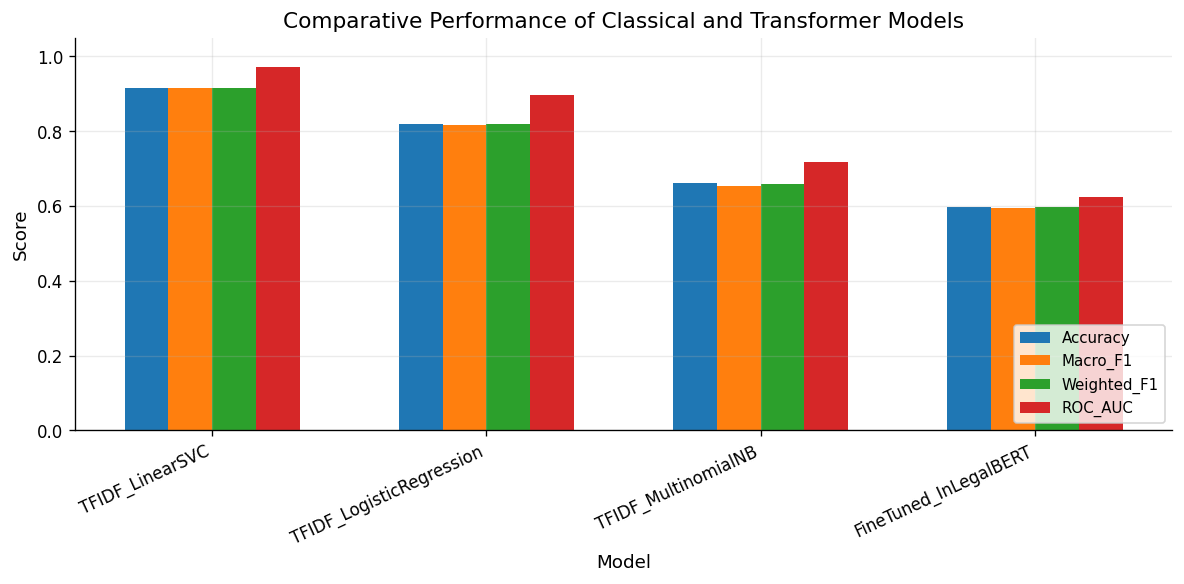

In [50]:
#Cell 32: Publication-grade combined comparison plot

metrics_to_plot = ["Accuracy", "Macro_F1", "Weighted_F1", "ROC_AUC"]

plot_df = combined_results_df.melt(
    id_vars=["Model"],
    value_vars=[m for m in metrics_to_plot if m in combined_results_df.columns],
    var_name="Metric",
    value_name="Score"
)

fig, ax = plt.subplots(figsize=(10, 5))

models = plot_df["Model"].unique()
metrics = plot_df["Metric"].unique()

x = np.arange(len(models))
width = 0.16

for i, metric in enumerate(metrics):
    values = []
    for model_name in models:
        v = plot_df[(plot_df["Model"] == model_name) & (plot_df["Metric"] == metric)]["Score"].values
        values.append(v[0] if len(v) else np.nan)
    ax.bar(x + i*width, values, width, label=metric)

ax.set_title("Comparative Performance of Classical and Transformer Models")
ax.set_xlabel("Model")
ax.set_ylabel("Score")
ax.set_ylim(0, 1.05)
ax.set_xticks(x + width * (len(metrics)-1)/2)
ax.set_xticklabels(models, rotation=25, ha="right")
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/combined_model_comparison.png", bbox_inches="tight")
plt.show()

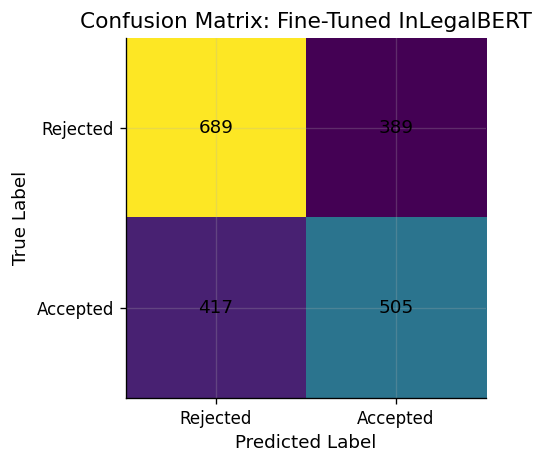

              precision    recall  f1-score   support

    Rejected       0.62      0.64      0.63      1078
    Accepted       0.56      0.55      0.56       922

    accuracy                           0.60      2000
   macro avg       0.59      0.59      0.59      2000
weighted avg       0.60      0.60      0.60      2000



In [51]:
# Cell 33: Confusion matrix for InLegalBERT

plot_confusion_matrix(
    y_true_transformer,
    y_pred_transformer,
    "Confusion Matrix: Fine-Tuned InLegalBERT",
    "inlegalbert_confusion_matrix.png"
)

print(classification_report(
    y_true_transformer,
    y_pred_transformer,
    target_names=["Rejected", "Accepted"]
))

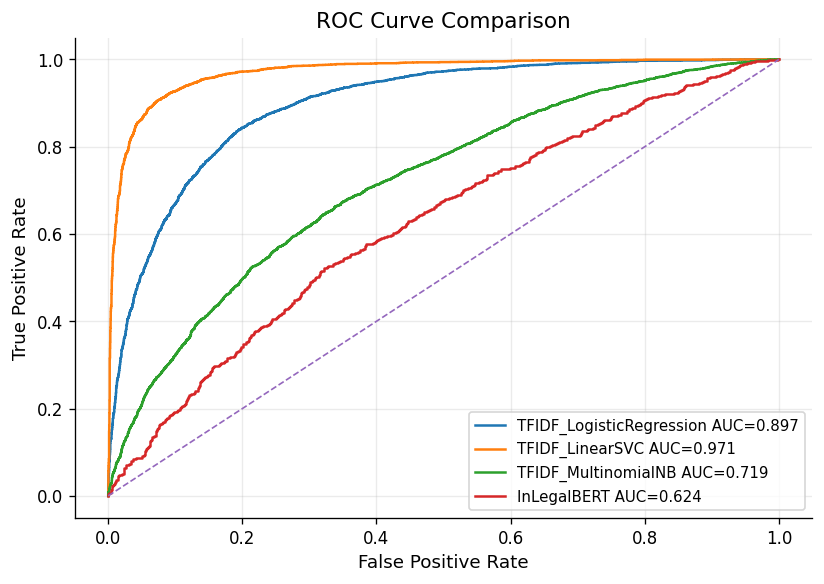

In [52]:
# Cell 34: ROC curve comparison

fig, ax = plt.subplots(figsize=(7, 5))

for model_name, pred_data in baseline_predictions.items():
    y_prob = pred_data["y_prob"]
    if y_prob is not None:
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        auc_value = roc_auc_score(y_test, y_prob)
        ax.plot(fpr, tpr, label=f"{model_name} AUC={auc_value:.3f}")

fpr, tpr, _ = roc_curve(y_true_transformer, y_prob_transformer)
auc_value = roc_auc_score(y_true_transformer, y_prob_transformer)
ax.plot(fpr, tpr, label=f"InLegalBERT AUC={auc_value:.3f}")

ax.plot([0, 1], [0, 1], linestyle="--", linewidth=1)

ax.set_title("ROC Curve Comparison")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/roc_curve_comparison.png", bbox_inches="tight")
plt.show()

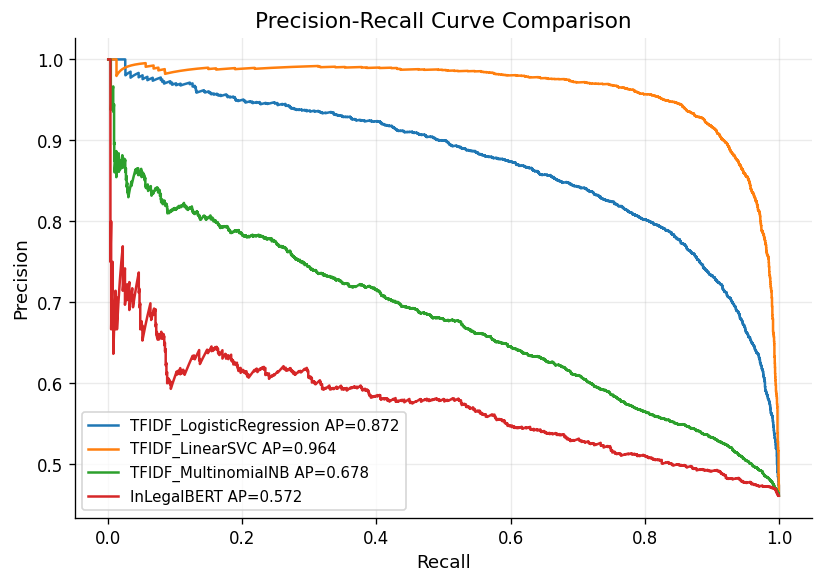

In [53]:
# Cell 35: Precision-recall curve comparison

fig, ax = plt.subplots(figsize=(7, 5))

for model_name, pred_data in baseline_predictions.items():
    y_prob = pred_data["y_prob"]
    if y_prob is not None:
        precision, recall, _ = precision_recall_curve(y_test, y_prob)
        ap = average_precision_score(y_test, y_prob)
        ax.plot(recall, precision, label=f"{model_name} AP={ap:.3f}")

precision, recall, _ = precision_recall_curve(y_true_transformer, y_prob_transformer)
ap = average_precision_score(y_true_transformer, y_prob_transformer)
ax.plot(recall, precision, label=f"InLegalBERT AP={ap:.3f}")

ax.set_title("Precision-Recall Curve Comparison")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.legend(loc="lower left")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/precision_recall_curve_comparison.png", bbox_inches="tight")
plt.show()

In [54]:
# Cell 36: Subgroup evaluation by civil and criminal cases

#Use best classical model first.

def subgroup_evaluation(model, df_subset, subset_name):
    X = df_subset["text"].values
    y = df_subset["target"].values

    y_pred = model.predict(X)

    if hasattr(model.named_steps["clf"], "predict_proba"):
        y_prob = model.predict_proba(X)[:, 1]
    elif hasattr(model.named_steps["clf"], "decision_function"):
        scores = model.decision_function(X)
        y_prob = (scores - scores.min()) / (scores.max() - scores.min() + 1e-9)
    else:
        y_prob = None

    return evaluate_predictions(
        y_true=y,
        y_pred=y_pred,
        y_prob=y_prob,
        model_name=best_baseline_name,
        subset_name=subset_name
    )

best_baseline_model = baseline_models[best_baseline_name]

subgroup_results = []

if len(civil_df) > 0:
    subgroup_results.append(subgroup_evaluation(best_baseline_model, civil_df, "Civil"))

if len(criminal_df) > 0:
    subgroup_results.append(subgroup_evaluation(best_baseline_model, criminal_df, "Criminal"))

subgroup_results_df = pd.DataFrame(subgroup_results)
subgroup_results_df

,Model,Subset,Accuracy,Macro_Precision,Macro_Recall,Macro_F1,Weighted_Precision,Weighted_Recall,Weighted_F1,ROC_AUC,Average_Precision
0,TFIDF_LinearSVC,Civil,0.9298,0.9294,0.9300,0.9296,0.9300,0.9298,0.9298,0.9808,0.9777
1,TFIDF_LinearSVC,Criminal,0.9474,0.9468,0.9477,0.9472,0.9476,0.9474,0.9475,0.9875,0.9857


In [55]:
# Cell 36A

print(subgroup_results_df.to_markdown(index=False))
subgroup_results_df.to_csv(f"{TAB_DIR}/subgroup_results.csv", index=False)

| Model           | Subset   |   Accuracy |   Macro_Precision |   Macro_Recall |   Macro_F1 |   Weighted_Precision |   Weighted_Recall |   Weighted_F1 |   ROC_AUC |   Average_Precision |
|:----------------|:---------|-----------:|------------------:|---------------:|-----------:|---------------------:|------------------:|--------------:|----------:|--------------------:|
| TFIDF_LinearSVC | Civil    |     0.9298 |            0.9294 |         0.93   |     0.9296 |               0.93   |            0.9298 |        0.9298 |    0.9808 |              0.9777 |
| TFIDF_LinearSVC | Criminal |     0.9474 |            0.9468 |         0.9477 |     0.9472 |               0.9476 |            0.9474 |        0.9475 |    0.9875 |              0.9857 |


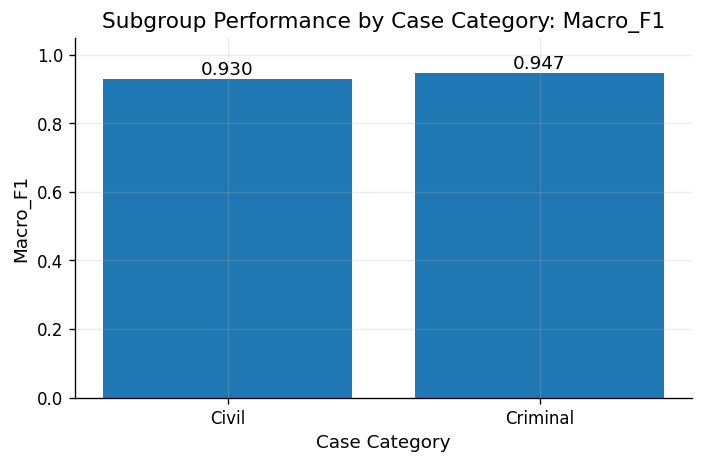

In [56]:
# Cell 37: Subgroup comparison plot

metric = "Macro_F1"

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(subgroup_results_df["Subset"], subgroup_results_df[metric])

for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:.3f}",
        ha="center",
        va="bottom"
    )

ax.set_title(f"Subgroup Performance by Case Category: {metric}")
ax.set_xlabel("Case Category")
ax.set_ylabel(metric)
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/subgroup_macro_f1.png", bbox_inches="tight")
plt.show()

In [57]:
# Cell 38: Top TF-IDF features for explainability

#This is useful for the paper because it gives interpretable legal lexical indicators.

def get_top_tfidf_features(pipeline, top_n=30):
    vectorizer = pipeline.named_steps["tfidf"]
    clf = pipeline.named_steps["clf"]

    feature_names = np.array(vectorizer.get_feature_names_out())

    if hasattr(clf, "coef_"):
        coefs = clf.coef_[0]

        top_positive_idx = np.argsort(coefs)[-top_n:][::-1]
        top_negative_idx = np.argsort(coefs)[:top_n]

        positive_df = pd.DataFrame({
            "Feature": feature_names[top_positive_idx],
            "Coefficient": coefs[top_positive_idx],
            "Associated_Class": "Accepted"
        })

        negative_df = pd.DataFrame({
            "Feature": feature_names[top_negative_idx],
            "Coefficient": coefs[top_negative_idx],
            "Associated_Class": "Rejected"
        })

        return pd.concat([positive_df, negative_df], ignore_index=True)

    return pd.DataFrame()

feature_importance_df = get_top_tfidf_features(best_baseline_model, top_n=25)
feature_importance_df

,Feature,Coefficient,Associated_Class
0,allowed,17.735527,Accepted
1,is allowed,15.895416,Accepted
2,appeal allowed,10.714591,Accepted
3,accordingly allowed,10.019137,Accepted
4,are allowed,9.867462,Accepted
5,allow,8.558025,Accepted
6,is set,7.679938,Accepted
7,we allow,7.368626,Accepted
8,set aside,6.861420,Accepted
9,allow this,6.646637,Accepted


In [58]:
# Cell 38A

print(feature_importance_df.to_markdown(index=False))
feature_importance_df.to_csv(f"{TAB_DIR}/tfidf_feature_importance.csv", index=False)

| Feature               |   Coefficient | Associated_Class   |
|:----------------------|--------------:|:-------------------|
| allowed               |      17.7355  | Accepted           |
| is allowed            |      15.8954  | Accepted           |
| appeal allowed        |      10.7146  | Accepted           |
| accordingly allowed   |      10.0191  | Accepted           |
| are allowed           |       9.86746 | Accepted           |
| allow                 |       8.55802 | Accepted           |
| is set                |       7.67994 | Accepted           |
| we allow              |       7.36863 | Accepted           |
| set aside             |       6.86142 | Accepted           |
| allow this            |       6.64664 | Accepted           |
| allowed with          |       6.31993 | Accepted           |
| allowed and           |       6.18707 | Accepted           |
| aside                 |       5.69021 | Accepted           |
| aside and             |       5.68933 | Accepted     

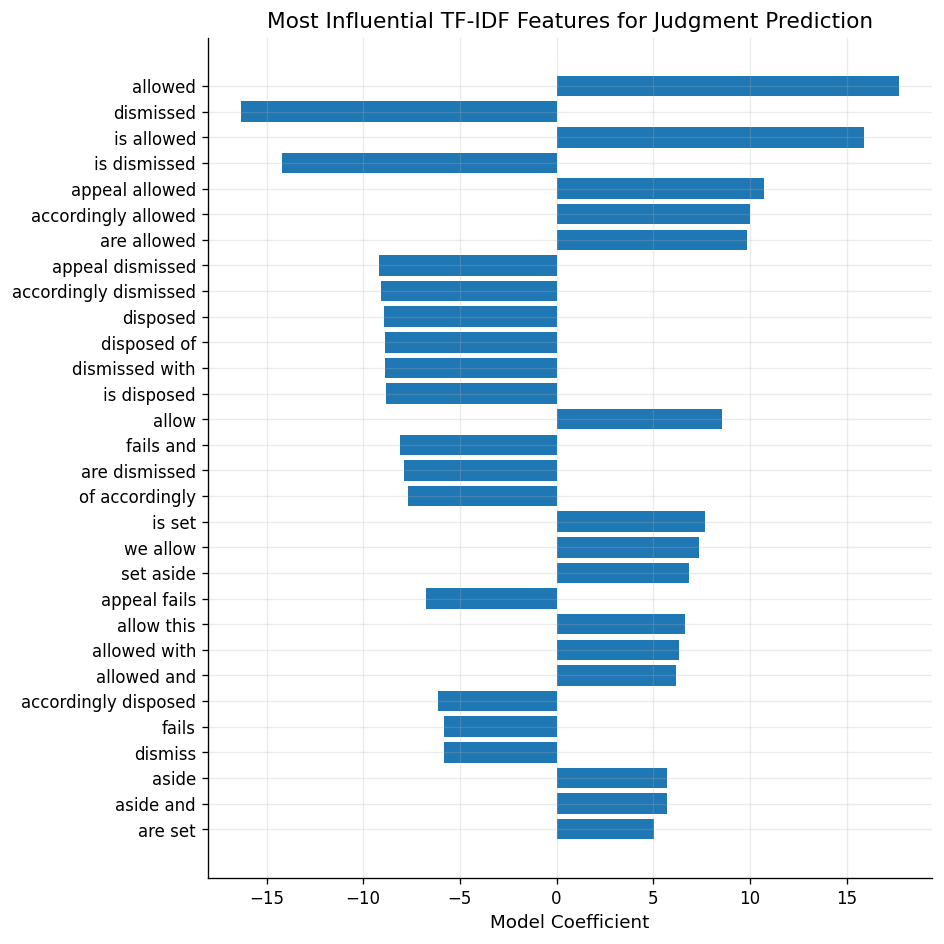

In [59]:
# Cell 39: Plot top features

plot_features = feature_importance_df.copy()
plot_features["Abs_Coefficient"] = plot_features["Coefficient"].abs()

top_plot = plot_features.sort_values("Abs_Coefficient", ascending=False).head(30)

fig, ax = plt.subplots(figsize=(8, 8))
y_pos = np.arange(len(top_plot))

ax.barh(y_pos, top_plot["Coefficient"])
ax.set_yticks(y_pos)
ax.set_yticklabels(top_plot["Feature"])
ax.invert_yaxis()
ax.set_title("Most Influential TF-IDF Features for Judgment Prediction")
ax.set_xlabel("Model Coefficient")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/tfidf_top_features.png", bbox_inches="tight")
plt.show()

In [60]:
# Cell 40: SHAP explainability for Logistic Regression baseline

# SHAP can be slow, so use a manageable sample.
import shap

if best_baseline_name != "TFIDF_LogisticRegression":
    shap_model = baseline_models["TFIDF_LogisticRegression"]
else:
    shap_model = best_baseline_model

sample_texts = test_df["text"].sample(n=min(200, len(test_df)), random_state=SEED).values

vectorizer = shap_model.named_steps["tfidf"]
classifier = shap_model.named_steps["clf"]

X_train_vec = vectorizer.transform(train_df["text"].sample(n=min(1000, len(train_df)), random_state=SEED))
X_sample_vec = vectorizer.transform(sample_texts)

explainer = shap.LinearExplainer(classifier, X_train_vec)
shap_values = explainer.shap_values(X_sample_vec)

feature_names = vectorizer.get_feature_names_out()

print("SHAP values computed.")

SHAP values computed.


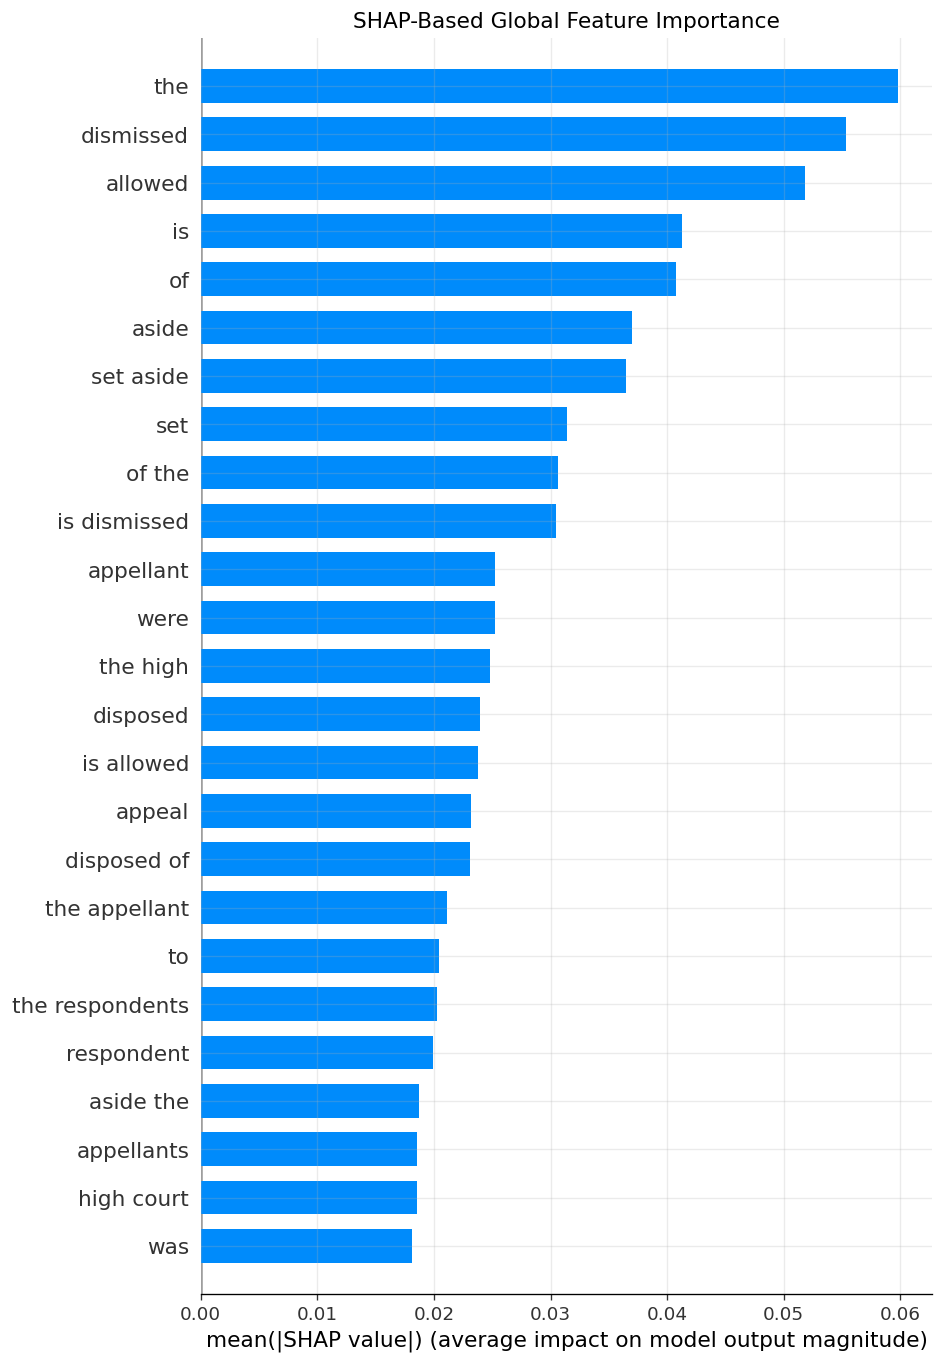

In [61]:
# Cell 41: SHAP summary bar plot

shap.summary_plot(
    shap_values,
    X_sample_vec,
    feature_names=feature_names,
    plot_type="bar",
    max_display=25,
    show=False
)

plt.title("SHAP-Based Global Feature Importance")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/shap_global_feature_importance.png", bbox_inches="tight")
plt.show()

In [62]:
#  Cell 42: Create SHAP table for paper

mean_abs_shap = np.abs(shap_values).mean(axis=0)

shap_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Mean_Absolute_SHAP": mean_abs_shap
}).sort_values("Mean_Absolute_SHAP", ascending=False).head(30)

shap_importance_df

,Feature,Mean_Absolute_SHAP
41843,the,0.059760
15403,dismissed,0.055326
4349,allowed,0.051816
23459,is,0.041311
29091,of,0.040768
7582,aside,0.036949
38745,set aside,0.036450
38743,set,0.031393
30394,of the,0.030603
23596,is dismissed,0.030467


In [63]:
# Cell 42 A

print(shap_importance_df.to_markdown(index=False))
shap_importance_df.to_csv(f"{TAB_DIR}/shap_importance_table.csv", index=False)


| Feature         |   Mean_Absolute_SHAP |
|:----------------|---------------------:|
| the             |            0.0597596 |
| dismissed       |            0.0553264 |
| allowed         |            0.0518159 |
| is              |            0.0413109 |
| of              |            0.0407677 |
| aside           |            0.0369488 |
| set aside       |            0.0364496 |
| set             |            0.0313932 |
| of the          |            0.0306028 |
| is dismissed    |            0.0304673 |
| appellant       |            0.025252  |
| were            |            0.0251979 |
| the high        |            0.0248278 |
| disposed        |            0.0239855 |
| is allowed      |            0.0237606 |
| appeal          |            0.0231322 |
| disposed of     |            0.0231115 |
| the appellant   |            0.0211414 |
| to              |            0.0204599 |
| the respondents |            0.0202331 |
| respondent      |            0.0199131 |
| aside the

In [64]:
# Cell 43: Counterfactual perturbation analysis

#This is an excellent novelty component.

LEGAL_TERMS_TO_REMOVE = [
    "appeal allowed",
    "appeal dismissed",
    "petition allowed",
    "petition dismissed",
    "conviction",
    "sentence",
    "acquittal",
    "high court",
    "supreme court",
    "constitution",
    "article",
    "section",
    "evidence",
    "respondent",
    "petitioner"
]

def perturb_text(text, terms):
    perturbed = text
    for term in terms:
        perturbed = re.sub(re.escape(term), " ", perturbed, flags=re.IGNORECASE)
    perturbed = re.sub(r"\s+", " ", perturbed).strip()
    return perturbed

cf_sample = test_df.sample(n=min(1000, len(test_df)), random_state=SEED).copy()

cf_sample["text_perturbed"] = cf_sample["text"].apply(
    lambda x: perturb_text(x, LEGAL_TERMS_TO_REMOVE)
)

original_pred = best_baseline_model.predict(cf_sample["text"].values)
perturbed_pred = best_baseline_model.predict(cf_sample["text_perturbed"].values)

cf_sample["original_pred"] = original_pred
cf_sample["perturbed_pred"] = perturbed_pred
cf_sample["prediction_changed"] = cf_sample["original_pred"] != cf_sample["perturbed_pred"]

counterfactual_summary = pd.DataFrame({
    "Total_Samples": [len(cf_sample)],
    "Changed_Predictions": [cf_sample["prediction_changed"].sum()],
    "Change_Rate_Percentage": [round(cf_sample["prediction_changed"].mean() * 100, 2)]
})

counterfactual_summary

,Total_Samples,Changed_Predictions,Change_Rate_Percentage
0,1000,32,3.2


In [65]:
# Cell 43A

print(counterfactual_summary.to_markdown(index=False))
counterfactual_summary.to_csv(f"{TAB_DIR}/counterfactual_summary.csv", index=False)

|   Total_Samples |   Changed_Predictions |   Change_Rate_Percentage |
|----------------:|----------------------:|-------------------------:|
|            1000 |                    32 |                      3.2 |


In [66]:
# Cell 44: Counterfactual examples

changed_examples = cf_sample[cf_sample["prediction_changed"] == True].copy()

changed_examples_table = changed_examples[[
    "name",
    "label",
    "original_pred",
    "perturbed_pred",
    "text_length_words"
]].head(20)

changed_examples_table["original_pred"] = changed_examples_table["original_pred"].map({0: "Rejected", 1: "Accepted"})
changed_examples_table["perturbed_pred"] = changed_examples_table["perturbed_pred"].map({0: "Rejected", 1: "Accepted"})

changed_examples_table

,name,label,original_pred,perturbed_pred,text_length_words
40720,1729239192.txt,Accepted,Accepted,Rejected,2770
36860,11518656.txt,Rejected,Accepted,Rejected,5562
41099,1792264.txt,Rejected,Accepted,Rejected,5582
41180,1793515.txt,Rejected,Accepted,Rejected,5693
40819,171510013.txt,Rejected,Rejected,Accepted,5696
39014,1655422.txt,Rejected,Accepted,Rejected,6564
36372,1755927.txt,Rejected,Accepted,Rejected,5392
34226,255979.txt,Accepted,Accepted,Rejected,4622
34164,246416.txt,Rejected,Accepted,Rejected,3392
34136,242759.txt,Accepted,Accepted,Rejected,2977


In [67]:
# Cell 44A

print(changed_examples_table.to_markdown(index=False))
changed_examples_table.to_csv(f"{TAB_DIR}/counterfactual_changed_examples.csv", index=False)

| name           | label    | original_pred   | perturbed_pred   |   text_length_words |
|:---------------|:---------|:----------------|:-----------------|--------------------:|
| 1729239192.txt | Accepted | Accepted        | Rejected         |                2770 |
| 11518656.txt   | Rejected | Accepted        | Rejected         |                5562 |
| 1792264.txt    | Rejected | Accepted        | Rejected         |                5582 |
| 1793515.txt    | Rejected | Accepted        | Rejected         |                5693 |
| 171510013.txt  | Rejected | Rejected        | Accepted         |                5696 |
| 1655422.txt    | Rejected | Accepted        | Rejected         |                6564 |
| 1755927.txt    | Rejected | Accepted        | Rejected         |                5392 |
| 255979.txt     | Accepted | Accepted        | Rejected         |                4622 |
| 246416.txt     | Rejected | Accepted        | Rejected         |                3392 |
| 242759.txt     | Ac

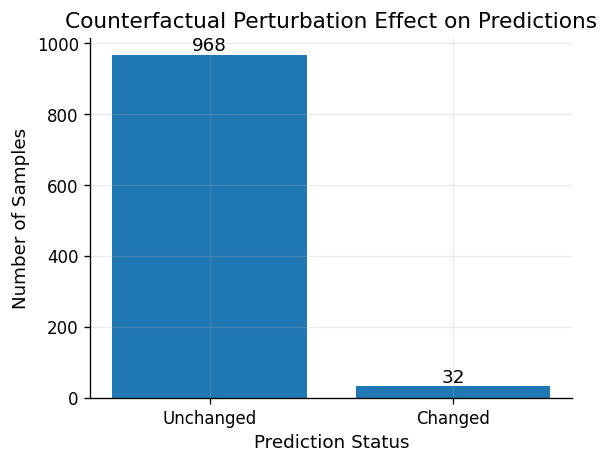

In [68]:
# Cell 45: Counterfactual change rate plot

fig, ax = plt.subplots(figsize=(5, 4))

counts = cf_sample["prediction_changed"].value_counts().rename({
    False: "Unchanged",
    True: "Changed"
})

bars = ax.bar(counts.index.astype(str), counts.values)

for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{int(height)}",
        ha="center",
        va="bottom"
    )

ax.set_title("Counterfactual Perturbation Effect on Predictions")
ax.set_xlabel("Prediction Status")
ax.set_ylabel("Number of Samples")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/counterfactual_change_rate.png", bbox_inches="tight")
plt.show()

In [69]:
# Cell 46: Error analysis table

error_df = test_df.copy()
error_df["predicted"] = best_baseline_pred
error_df["predicted_label"] = error_df["predicted"].map({0: "Rejected", 1: "Accepted"})
error_df["correct"] = error_df["target"] == error_df["predicted"]

error_summary = pd.crosstab(
    error_df["label"],
    error_df["predicted_label"],
    margins=True
)

error_summary

predicted_label,Accepted,Rejected,All
label,,,
Accepted,3578,327,3905
Rejected,394,4170,4564
All,3972,4497,8469


In [70]:
# Cell 46A

print(error_summary.to_markdown())
error_summary.to_csv(f"{TAB_DIR}/error_summary.csv")

| label    |   Accepted |   Rejected |   All |
|:---------|-----------:|-----------:|------:|
| Accepted |       3578 |        327 |  3905 |
| Rejected |        394 |       4170 |  4564 |
| All      |       3972 |       4497 |  8469 |


In [71]:
# Cell 47: Save misclassified examples

misclassified_examples = error_df[error_df["correct"] == False][[
    "name",
    "case_category",
    "case_type",
    "label",
    "predicted_label",
    "text_length_words",
    "proof_sentence"
]].head(50)

misclassified_examples

,name,case_category,case_type,label,predicted_label,text_length_words,proof_sentence
33878,1997357.txt,civil,writ petition,Rejected,Accepted,4258,32. the appeals are disposed of accordingly.
33881,1997550.txt,nan,appeal,Accepted,Rejected,1163,1. this appeal on special leave being granted ...
33884,1997821.txt,civil,appeal,Accepted,Rejected,983,"for the afore-stated reasons, civil appeal is ..."
33885,199787688.txt,civil,writ petition,Rejected,Accepted,5092,"subject to above, the appeal is dismissed."
33891,1999266.txt,civil,appeal,Accepted,Rejected,4992,appeals allowed.
33896,19999960.txt,civil,appeal,Rejected,Accepted,4383,29. in view of our order passed in criminal ap...
33905,200848.txt,criminal,appeal,Rejected,Accepted,1448,17. all the appeals are disposed of in the abo...
33907,200923.txt,civil,appeal,Accepted,Rejected,4999,appeals allowed.
33912,201568.txt,civil,writ petition,Rejected,Accepted,4495,appeals dismissed.
33913,202749.txt,civil,writ petition,Accepted,Rejected,5329,appeal allowed in part.


In [72]:
# Cell 47A

print(misclassified_examples.to_markdown(index=False))
misclassified_examples.to_csv(f"{TAB_DIR}/misclassified_examples.csv", index=False)

| name          | case_category   | case_type              | label    | predicted_label   |   text_length_words | proof_sentence                                                                                                                                                                                                                                                                                                                                                                                                                                                                                           |
|:--------------|:----------------|:-----------------------|:---------|:------------------|--------------------:|:-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [73]:
# Cell 48: Generate publication-ready summary table

publication_summary = combined_results_df[[
    "Model",
    "Subset",
    "Accuracy",
    "Macro_Precision",
    "Macro_Recall",
    "Macro_F1",
    "Weighted_F1",
    "ROC_AUC",
    "Training_Time_Sec"
]].copy()

publication_summary

,Model,Subset,Accuracy,Macro_Precision,Macro_Recall,Macro_F1,Weighted_F1,ROC_AUC,Training_Time_Sec
1,TFIDF_LinearSVC,Overall,0.9149,0.9140,0.9150,0.9144,0.9149,0.9710,318.88
0,TFIDF_LogisticRegression,Overall,0.8185,0.8173,0.8181,0.8176,0.8186,0.8967,211.89
2,TFIDF_MultinomialNB,Overall,0.6627,0.6631,0.6539,0.6534,0.6578,0.7188,267.77
3,FineTuned_InLegalBERT,Sampled_Test_Set,0.5970,0.5939,0.5934,0.5936,0.5965,0.6237,1580.05


In [74]:
# Cell 49: Save all result tables to Excel

excel_path = "/content/judipl_results_tables.xlsx"

with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:
    audit_table.to_excel(writer, sheet_name="Dataset_Audit", index=False)
    desc_table.to_excel(writer, sheet_name="Descriptive_Stats")
    label_counts.to_excel(writer, sheet_name="Label_Distribution", index=False)
    category_counts.to_excel(writer, sheet_name="Category_Distribution", index=False)
    baseline_results_df.to_excel(writer, sheet_name="Baseline_Results", index=False)
    transformer_results_df.to_excel(writer, sheet_name="Transformer_Results", index=False)
    combined_results_df.to_excel(writer, sheet_name="Combined_Results", index=False)
    subgroup_results_df.to_excel(writer, sheet_name="Subgroup_Results", index=False)
    feature_importance_df.to_excel(writer, sheet_name="TFIDF_Features", index=False)
    shap_importance_df.to_excel(writer, sheet_name="SHAP_Importance", index=False)
    counterfactual_summary.to_excel(writer, sheet_name="Counterfactual_Summary", index=False)
    changed_examples_table.to_excel(writer, sheet_name="Counterfactual_Examples", index=False)
    misclassified_examples.to_excel(writer, sheet_name="Misclassified", index=False)

excel_path

'/content/judipl_results_tables.xlsx'

In [75]:
# Cell 49A: Download:

from google.colab import files
files.download(excel_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [76]:
# Cell 50: Zip all figures

!zip -r /content/judipl_publication_figures.zip /content/figures
files.download("/content/judipl_publication_figures.zip")

  adding: content/figures/ (stored 0%)
  adding: content/figures/outcome_by_case_category.png (deflated 23%)
  adding: content/figures/inlegalbert_confusion_matrix.png (deflated 16%)
  adding: content/figures/subgroup_macro_f1.png (deflated 21%)
  adding: content/figures/precision_recall_curve_comparison.png (deflated 7%)
  adding: content/figures/tfidf_top_features.png (deflated 23%)
  adding: content/figures/best_baseline_confusion_matrix.png (deflated 18%)
  adding: content/figures/counterfactual_change_rate.png (deflated 18%)
  adding: content/figures/combined_model_comparison.png (deflated 18%)
  adding: content/figures/case_category_distribution.png (deflated 22%)
  adding: content/figures/roc_curve_comparison.png (deflated 9%)
  adding: content/figures/text_length_distribution.png (deflated 22%)
  adding: content/figures/shap_global_feature_importance.png (deflated 27%)
  adding: content/figures/baseline_model_comparison.png (deflated 20%)
  adding: content/figures/label_distrib

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Extra Cells Below

In [77]:
# Cell 51
# Can be placed with a subsection "Shortcut Sensitivity and Outcome-Phrase Ablation"

# Leakage / shortcut phrase removal experiment

OUTCOME_PHRASES = [
    "appeal allowed", "appeal is allowed", "appeal dismissed", "appeal is dismissed",
    "petition allowed", "petition is allowed", "petition dismissed", "petition is dismissed",
    "application allowed", "application dismissed",
    "writ petition allowed", "writ petition dismissed",
    "criminal appeal allowed", "criminal appeal dismissed",
    "civil appeal allowed", "civil appeal dismissed",
    "the appeal succeeds", "the appeal fails",
    "we allow the appeal", "we dismiss the appeal",
    "accordingly the appeal is allowed",
    "accordingly the appeal is dismissed"
]

def remove_outcome_phrases(text):
    text = str(text)
    for phrase in OUTCOME_PHRASES:
        text = re.sub(re.escape(phrase), " ", text, flags=re.IGNORECASE)
    text = re.sub(r"\s+", " ", text).strip()
    return text

train_df_leak = train_df.copy()
test_df_leak = test_df.copy()

train_df_leak["text_no_shortcuts"] = train_df_leak["text"].apply(remove_outcome_phrases)
test_df_leak["text_no_shortcuts"] = test_df_leak["text"].apply(remove_outcome_phrases)

leak_model = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=50000, ngram_range=(1, 2), min_df=3)),
    ("clf", LinearSVC(class_weight="balanced"))
])

leak_model.fit(train_df_leak["text_no_shortcuts"], train_df_leak["target"])
leak_pred = leak_model.predict(test_df_leak["text_no_shortcuts"])

leak_result = evaluate_predictions(
    y_true=test_df_leak["target"],
    y_pred=leak_pred,
    model_name="TFIDF_LinearSVC_No_Outcome_Phrases",
    subset_name="Shortcut_Removed"
)

pd.DataFrame([leak_result])

,Model,Subset,Accuracy,Macro_Precision,Macro_Recall,Macro_F1,Weighted_Precision,Weighted_Recall,Weighted_F1
0,TFIDF_LinearSVC_No_Outcome_Phrases,Shortcut_Removed,0.9003,0.8994,0.9005,0.8999,0.9006,0.9003,0.9004


In [78]:
# Cell 52

# Use proof_sentence as an explanation benchmark

# The dataset has proof_sentence, which is highly valuable. You can compare whether the model’s important TF-IDF/SHAP words overlap with proof sentences.

#This gives you a stronger XAI contribution.

# Proof sentence coverage analysis

# Paper angle: We further compare globally important SHAP terms with dataset-provided proof sentences to examine whether the explanation layer aligns with human-identified outcome-supporting textual evidence.

test_explain = test_df.copy()
test_explain["proof_sentence_clean"] = test_explain["proof_sentence"].fillna("").apply(clean_text)

def keyword_overlap(text, proof_sentence, top_terms):
    proof_tokens = set(str(proof_sentence).split())
    selected_terms = set(top_terms)
    if len(selected_terms) == 0:
        return 0
    return len(proof_tokens.intersection(selected_terms)) / len(selected_terms)

top_global_terms = shap_importance_df["Feature"].head(30).tolist()

test_explain["proof_overlap_score"] = test_explain["proof_sentence_clean"].apply(
    lambda x: keyword_overlap("", x, top_global_terms)
)

proof_overlap_summary = test_explain["proof_overlap_score"].describe().round(4)
proof_overlap_summary

,proof_overlap_score
count,8469.0000
mean,0.1115
std,0.0672
min,0.0000
25%,0.0333
50%,0.1000
75%,0.1667
max,0.4667


In [79]:
# Cell 53

# Case-type-wise performance
# We already considered civil/criminal. Add case_type performance also. This will make the analysis more legally meaningful.

# Case-type-wise performance of best model

case_type_results = []

for ct, subdf in test_df.groupby("case_type"):
    if len(subdf) < 50:
        continue

    y_true_ct = subdf["target"].values
    y_pred_ct = best_baseline_model.predict(subdf["text"].values)

    result = evaluate_predictions(
        y_true=y_true_ct,
        y_pred=y_pred_ct,
        model_name=best_baseline_name,
        subset_name=str(ct)
    )

    result["N"] = len(subdf)
    case_type_results.append(result)

case_type_results_df = pd.DataFrame(case_type_results)
case_type_results_df = case_type_results_df.sort_values("Macro_F1", ascending=False)

case_type_results_df

,Model,Subset,Accuracy,Macro_Precision,Macro_Recall,Macro_F1,Weighted_Precision,Weighted_Recall,Weighted_F1,N
0,TFIDF_LinearSVC,appeal,0.9275,0.9268,0.9276,0.9272,0.9277,0.9275,0.9276,4775
2,TFIDF_LinearSVC,election petition,0.9189,0.9233,0.8978,0.9085,0.9199,0.9189,0.9177,148
3,TFIDF_LinearSVC,review petition,0.9000,0.9032,0.9012,0.8999,0.9043,0.9000,0.8999,80
5,TFIDF_LinearSVC,writ petition,0.8983,0.8978,0.8985,0.8981,0.8985,0.8983,0.8983,2752
4,TFIDF_LinearSVC,special leave petition,0.8974,0.8945,0.8973,0.8957,0.8981,0.8974,0.8976,585
1,TFIDF_LinearSVC,contempt petition,0.8667,0.8668,0.8671,0.8667,0.8673,0.8667,0.8667,105


In [80]:
# Copy-paste table:

print(case_type_results_df.to_markdown(index=False))
case_type_results_df.to_csv(f"{TAB_DIR}/case_type_performance.csv", index=False)



| Model           | Subset                 |   Accuracy |   Macro_Precision |   Macro_Recall |   Macro_F1 |   Weighted_Precision |   Weighted_Recall |   Weighted_F1 |    N |
|:----------------|:-----------------------|-----------:|------------------:|---------------:|-----------:|---------------------:|------------------:|--------------:|-----:|
| TFIDF_LinearSVC | appeal                 |     0.9275 |            0.9268 |         0.9276 |     0.9272 |               0.9277 |            0.9275 |        0.9276 | 4775 |
| TFIDF_LinearSVC | election petition      |     0.9189 |            0.9233 |         0.8978 |     0.9085 |               0.9199 |            0.9189 |        0.9177 |  148 |
| TFIDF_LinearSVC | review petition        |     0.9    |            0.9032 |         0.9012 |     0.8999 |               0.9043 |            0.9    |        0.8999 |   80 |
| TFIDF_LinearSVC | writ petition          |     0.8983 |            0.8978 |         0.8985 |     0.8981 |               0.8985 |

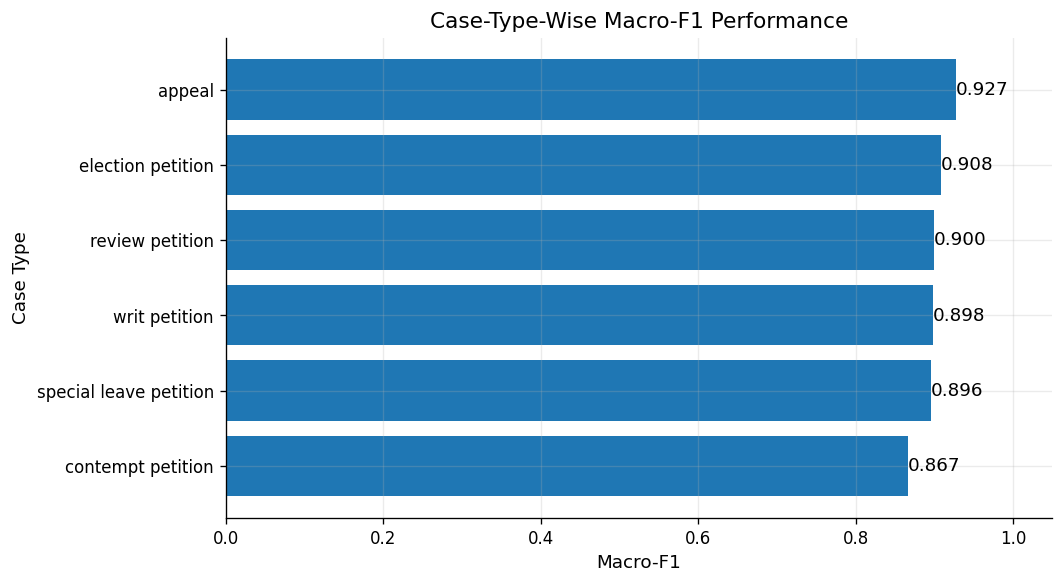

In [81]:
# Plot

fig, ax = plt.subplots(figsize=(9, 5))

plot_df = case_type_results_df.sort_values("Macro_F1", ascending=True)

ax.barh(plot_df["Subset"], plot_df["Macro_F1"])

for i, v in enumerate(plot_df["Macro_F1"]):
    ax.text(v, i, f"{v:.3f}", va="center")

ax.set_title("Case-Type-Wise Macro-F1 Performance")
ax.set_xlabel("Macro-F1")
ax.set_ylabel("Case Type")
ax.set_xlim(0, 1.05)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/case_type_macro_f1.png", bbox_inches="tight")
plt.show()

In [82]:
# Cell 54

# Document-length effect analysis

# Legal documents are long. Reviewers may ask whether the model performs equally well on short and long judgments.

# Create length bins and compare performance.


# Performance by document length

length_df = test_df.copy()
length_df["length_bin"] = pd.qcut(
    length_df["text_length_words"],
    q=4,
    labels=["Very Short", "Short", "Long", "Very Long"]
)

length_results = []

for bin_name, subdf in length_df.groupby("length_bin"):
    y_true_bin = subdf["target"].values
    y_pred_bin = best_baseline_model.predict(subdf["text"].values)

    result = evaluate_predictions(
        y_true=y_true_bin,
        y_pred=y_pred_bin,
        model_name=best_baseline_name,
        subset_name=str(bin_name)
    )

    result["N"] = len(subdf)
    result["Mean_Text_Length"] = round(subdf["text_length_words"].mean(), 2)
    length_results.append(result)

length_results_df = pd.DataFrame(length_results)
length_results_df

,Model,Subset,Accuracy,Macro_Precision,Macro_Recall,Macro_F1,Weighted_Precision,Weighted_Recall,Weighted_F1,N,Mean_Text_Length
0,TFIDF_LinearSVC,Very Short,0.9514,0.9491,0.9525,0.9506,0.9520,0.9514,0.9515,2120,869.43
1,TFIDF_LinearSVC,Short,0.9376,0.9376,0.9381,0.9376,0.9381,0.9376,0.9376,2115,2046.91
2,TFIDF_LinearSVC,Long,0.9197,0.9192,0.9198,0.9195,0.9198,0.9197,0.9197,2117,3461.51
3,TFIDF_LinearSVC,Very Long,0.8507,0.8501,0.8495,0.8498,0.8507,0.8507,0.8507,2117,5620.84


In [83]:
# Copy paste

print(length_results_df.to_markdown(index=False))
length_results_df.to_csv(f"{TAB_DIR}/length_bin_performance.csv", index=False)

| Model           | Subset     |   Accuracy |   Macro_Precision |   Macro_Recall |   Macro_F1 |   Weighted_Precision |   Weighted_Recall |   Weighted_F1 |    N |   Mean_Text_Length |
|:----------------|:-----------|-----------:|------------------:|---------------:|-----------:|---------------------:|------------------:|--------------:|-----:|-------------------:|
| TFIDF_LinearSVC | Very Short |     0.9514 |            0.9491 |         0.9525 |     0.9506 |               0.952  |            0.9514 |        0.9515 | 2120 |             869.43 |
| TFIDF_LinearSVC | Short      |     0.9376 |            0.9376 |         0.9381 |     0.9376 |               0.9381 |            0.9376 |        0.9376 | 2115 |            2046.91 |
| TFIDF_LinearSVC | Long       |     0.9197 |            0.9192 |         0.9198 |     0.9195 |               0.9198 |            0.9197 |        0.9197 | 2117 |            3461.51 |
| TFIDF_LinearSVC | Very Long  |     0.8507 |            0.8501 |         0.8495 |   

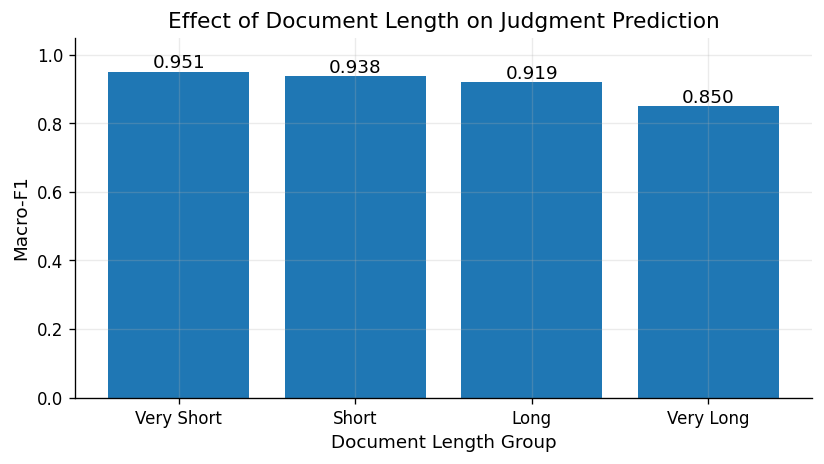

In [84]:
# Plot

fig, ax = plt.subplots(figsize=(7, 4))

bars = ax.bar(length_results_df["Subset"], length_results_df["Macro_F1"])

for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:.3f}",
        ha="center",
        va="bottom"
    )

ax.set_title("Effect of Document Length on Judgment Prediction")
ax.set_xlabel("Document Length Group")
ax.set_ylabel("Macro-F1")
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/length_bin_macro_f1.png", bbox_inches="tight")
plt.show()

In [85]:
# Cell 54

# Calibration analysis

# For legal AI, confidence matters. Logistic Regression gives probability directly. LinearSVC can be calibrated using CalibratedClassifierCV.

# This is valuable for legal decision support.

from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.svm import LinearSVC

calibrated_svc = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=50000, ngram_range=(1, 2), min_df=3)),
    ("clf", CalibratedClassifierCV(
        estimator=LinearSVC(class_weight="balanced"),
        method="sigmoid",
        cv=3
    ))
])

start = time.time()
calibrated_svc.fit(train_df["text"], train_df["target"])
calibrated_time = time.time() - start

calibrated_pred = calibrated_svc.predict(test_df["text"])
calibrated_prob = calibrated_svc.predict_proba(test_df["text"])[:, 1]

calibrated_result = evaluate_predictions(
    y_true=test_df["target"],
    y_pred=calibrated_pred,
    y_prob=calibrated_prob,
    model_name="Calibrated_TFIDF_LinearSVC",
    subset_name="Overall"
)

calibrated_result["Training_Time_Sec"] = round(calibrated_time, 2)

pd.DataFrame([calibrated_result])

,Model,Subset,Accuracy,Macro_Precision,Macro_Recall,Macro_F1,Weighted_Precision,Weighted_Recall,Weighted_F1,ROC_AUC,Average_Precision,Training_Time_Sec
0,Calibrated_TFIDF_LinearSVC,Overall,0.8976,0.8973,0.8966,0.8969,0.8976,0.8976,0.8976,0.9605,0.9523,198.75


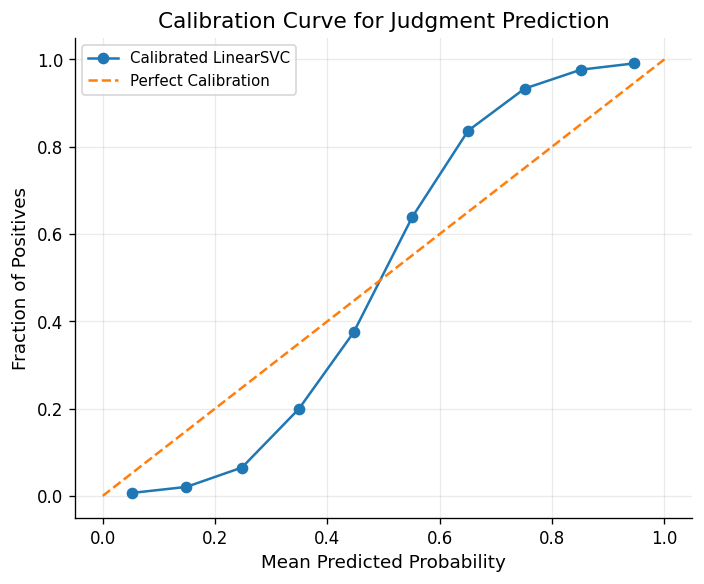

In [86]:
# Calibration curve:

prob_true, prob_pred = calibration_curve(
    test_df["target"],
    calibrated_prob,
    n_bins=10
)

fig, ax = plt.subplots(figsize=(6, 5))

ax.plot(prob_pred, prob_true, marker="o", label="Calibrated LinearSVC")
ax.plot([0, 1], [0, 1], linestyle="--", label="Perfect Calibration")

ax.set_title("Calibration Curve for Judgment Prediction")
ax.set_xlabel("Mean Predicted Probability")
ax.set_ylabel("Fraction of Positives")
ax.legend()
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/calibration_curve.png", bbox_inches="tight")
plt.show()